In [1]:
pwd()

'/home/user/Documents/repos/pyptv/pyptv'

In [2]:
import optv
import pathlib
import os
import matplotlib.pyplot as plt


In [3]:
from optv.imgcoord import image_coordinates  # type: ignore
from optv.transforms import convert_arr_metric_to_pixel  # type: ignore
from optv.orientation import match_detection_to_ref  # type: ignore
from optv.orientation import external_calibration, full_calibration  # type: ignore
from optv.calibration import Calibration  # type: ignore
from optv.tracking_framebuf import TargetArray  # type: ignore

In [4]:
# PyPTV works only inside the working folder
# working_folder = pathlib.Path('../tests/test_cavity/')
working_folder = pathlib.Path('/home/user/Downloads/test_8/')
os.chdir(working_folder)


working_folder = pathlib.Path('.')
par_path = working_folder / "parameters"

In [5]:
with open(par_path / "ptv.par", "r", encoding="utf8") as f:
    n_cams = int(f.readline())
    
print(f'{n_cams} cameras setup')

4 cameras setup


In [6]:
from ptv import *

In [7]:
# Read all the parameters in respective structures
cpar, spar, vpar, track_par, tpar, cals, epar = py_start_proc_c(n_cams)

In [8]:
cpar.get_allCam_flag()

False

In [9]:
# this is the default targ_rec.par for images
tpar.get_grey_thresholds()

array([120, 125, 125, 125], dtype=int32)

In [10]:
# we need for calibration:
tpar.read(b"parameters/detect_plate.par")
tpar.get_grey_thresholds()

array([120, 125, 125, 125], dtype=int32)

In [11]:
import parameters as par
from skimage.util import img_as_ubyte

In [12]:
calParams = par.CalOriParams(n_cams, par_path)
calParams.read()

In [13]:
if epar.Combine_Flag is True:
    print("Combine Flag")
    MultiParams = par.MultiPlaneParams()
    MultiParams.read()
    for i in range(MultiParams.n_planes):
        print(MultiParams.plane_name[i])

    pass_raw_orient = True
    status_text = "Multiplane calibration."

In [14]:
# read calibration images
cal_images = []
for i in range(n_cams):
    imname = calParams.img_cal_name[i]
    # for imname in calParams.img_cal_name:
    # cal_images.append(imread(imname))
    im = imread(imname)
    if im.ndim > 2:
        im = rgb2gray(im)

    cal_images.append(img_as_ubyte(im))

In [15]:
camera_dict = {'man_ori':np.zeros((4,)), '_x':[], '_y':[]}

In [16]:
import copy
# Loading manual parameters here
man_ori_path =  par_path / "man_ori.par"
camera = []
with open(man_ori_path, "r", encoding='utf8') as f:
    for i in range(n_cams):
        camera.append(copy.deepcopy(camera_dict))
        for j in range(4):
            camera[i]["man_ori"][j] = int(f.readline().strip())

In [17]:
cals = []
for i_cam in range(n_cams):
    cal = Calibration()
    tmp = cpar.get_cal_img_base_name(i_cam)
    cal.from_file(tmp + b".ori", tmp + b".addpar")
    cals.append(cal)
    
for i_cam in range(n_cams):
    print(cals[i_cam].get_pos())

[-55.04919141  69.08011566 285.7222193 ]
[ 38.31027202  71.06044027 307.79463114]
[-88.8110686  -25.20250785 295.26809485]
[-10.89499922  -7.32597112 310.67545104]


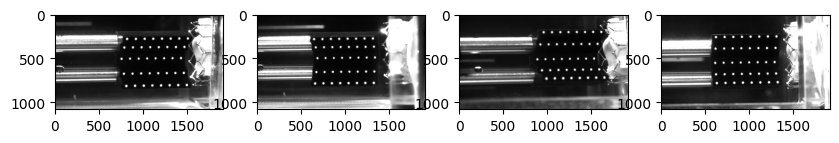

In [18]:
fig, ax = plt.subplots(1,4, figsize=(10,10))
                       
for i,c in enumerate(cal_images):
    ax[i].imshow(c, cmap='gray')
    # ax[i].plot(camera[i].man_ori[j])

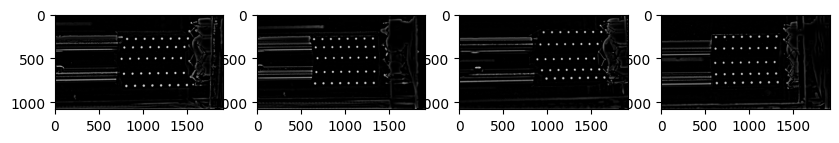

In [19]:
# highpass
high_passed = py_pre_processing_c(cal_images, cpar)

fig, ax = plt.subplots(1,4, figsize=(10,10))
                       
for i,c in enumerate(high_passed):
    ax[i].imshow(c, cmap='gray')
    # ax[i].plot(camera[i].man_ori[j])

In [20]:
detections, corrected = py_detection_proc_c(
    high_passed, cpar, tpar, cals)

Inside segmentation.pyx 

Calling liboptv 

Freeing targs and ret 

Free memory, filling t with 56 targets 

Returning t 

Inside segmentation.pyx 

Calling liboptv 

Freeing targs and ret 

Free memory, filling t with 45 targets 

Returning t 

Inside segmentation.pyx 

Calling liboptv 

Freeing targs and ret 

Free memory, filling t with 50 targets 

Returning t 

Inside segmentation.pyx 

Calling liboptv 

Freeing targs and ret 

Free memory, filling t with 47 targets 

Returning t 



In [21]:
x = [[i.pos()[0] for i in row] for row in detections]
y = [[i.pos()[1] for i in row] for row in detections]

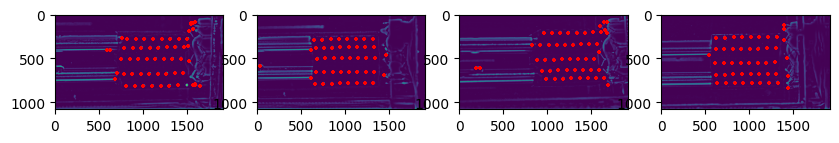

In [22]:
fig, ax = plt.subplots(1,n_cams,figsize=(10,10))
for i,c in enumerate(high_passed):
    ax[i].imshow(c)
    ax[i].scatter(x[i], y[i], 5, marker='+',color='r')

[818.0, 1510.0, 1501.0, 762.0] [284.0, 279.0, 808.0, 512.0]
[649.0, 1321.0, 1326.0, 686.0] [285.0, 277.0, 784.0, 504.0]
[964.0, 1619.0, 1652.0, 893.0] [208.0, 206.0, 722.0, 512.0]
[626.0, 1315.0, 1326.0, 616.0] [261.0, 256.0, 778.0, 558.0]


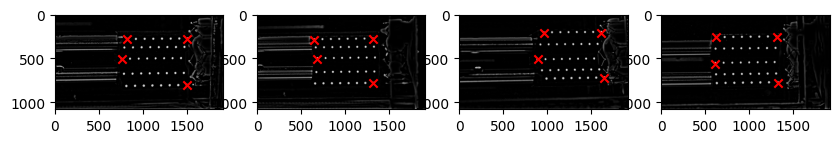

In [23]:
fig, ax = plt.subplots(1, n_cams, figsize=(10,10))
man_ori_path = "man_ori.dat"
with open(man_ori_path, "r") as f:
    for i in range(n_cams):
        camera[i]["_x"], camera[i]["_y"] = [], []
        for j in range(4):  # 4 orientation points
            line = f.readline().split()
            # print(line)
            # print(float(line[0]), float(line[1]))
            camera[i]["_x"].append(float(line[0]))
            camera[i]["_y"].append(float(line[1]))
        
        print(camera[i]["_x"], camera[i]["_y"])
        
        ax[i].imshow(high_passed[i], cmap='gray')
        ax[i].scatter(camera[i]["_x"], camera[i]["_y"], marker='x',color='red')

In [24]:
print(camera)

[{'man_ori': array([ 1.,  8., 40., 17.]), '_x': [818.0, 1510.0, 1501.0, 762.0], '_y': [284.0, 279.0, 808.0, 512.0]}, {'man_ori': array([ 1.,  8., 40., 17.]), '_x': [649.0, 1321.0, 1326.0, 686.0], '_y': [285.0, 277.0, 784.0, 504.0]}, {'man_ori': array([ 1.,  8., 40., 17.]), '_x': [964.0, 1619.0, 1652.0, 893.0], '_y': [208.0, 206.0, 722.0, 512.0]}, {'man_ori': array([ 1.,  8., 40., 17.]), '_x': [626.0, 1315.0, 1326.0, 616.0], '_y': [261.0, 256.0, 778.0, 558.0]}]


In [25]:
# later use for manual clicks
# https://matplotlib.org/stable/gallery/event_handling/cursor_demo.html
# skip this for now

In [26]:
def _read_cal_points():
    return np.atleast_1d(
        np.loadtxt(
            pathlib.Path(calParams.fixp_name),
            dtype=[("id", "i4"), ("pos", "3f8")],
            skiprows=0,
        ))

In [27]:
cal_points = _read_cal_points()

In [28]:
def drawcross(xlabel, ylabel, x, y, color, size, i_cam):
    ax[i_cam].scatter(x[i], y[i], 5, marker='+',color=color)

In [29]:
def _project_cal_points(i_cam, color="red"):
    x, y = [], []
    for row in cal_points:
        projected = image_coordinates(
            np.atleast_2d(row["pos"]),
            cals[i_cam],
            cpar.get_multimedia_params(),
        )
        pos = convert_arr_metric_to_pixel(projected, cpar)

        x.append(pos[0][0])
        y.append(pos[0][1])
        
    return x,y

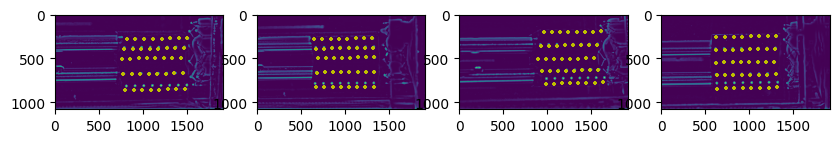

In [98]:
fig, ax = plt.subplots(1,n_cams,figsize=(10,10))
for i,c in enumerate(high_passed):
    ax[i].imshow(c)
    x,y = _project_cal_points(i)
    ax[i].scatter(x, y, 5, marker='+',color='y')

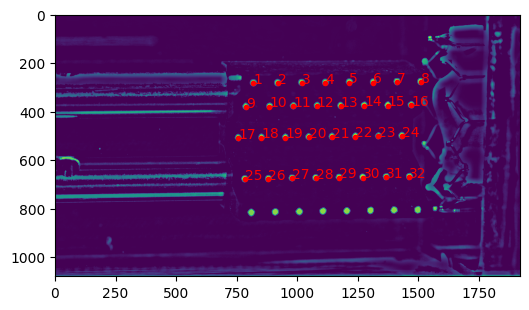

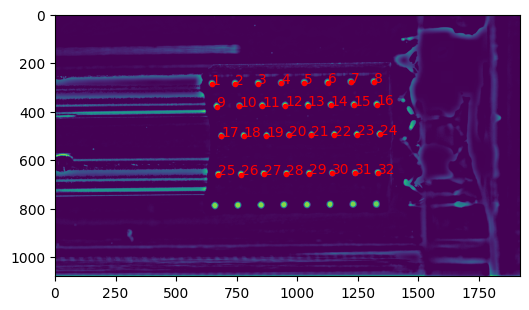

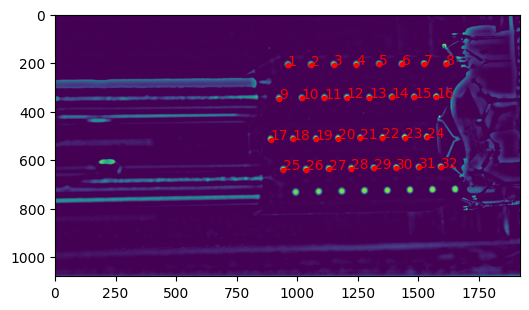

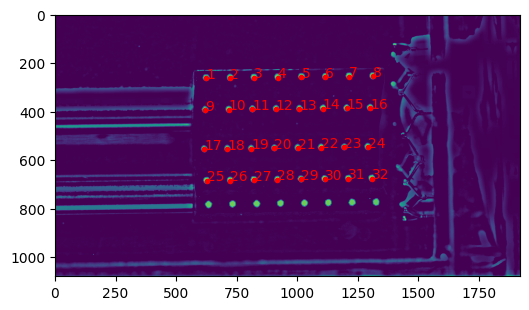

In [31]:
# sortgrid
"""
Uses sortgrid function of liboptv to match between the
calibration points in the fixp target file and the targets
detected in the images
"""
sorted_targs = []
for i_cam in range(n_cams):
    fig, ax = plt.subplots(figsize=(6,6))

    targs = match_detection_to_ref(
        cals[i_cam],
        cal_points["pos"],
        detections[i_cam],
        cpar,
    )
    x, y, pnr = [], [], []
    for t in targs:
        if t.pnr() != -999:
            pnr.append(cal_points["id"][t.pnr()])
            x.append(t.pos()[0])
            y.append(t.pos()[1])

    ax.imshow(high_passed[i_cam])
    ax.scatter(x,y,marker='.', color='r')
    for xx,yy,ss in zip(x,y,pnr):
        ax.text(xx,yy,ss,color='r')
    # ax.text(x,y,pnr)
    
    sorted_targs.append(targs)

In [32]:
cal_points

array([( 1, [  0. ,   0. ,   0. ]), ( 2, [  3. ,   0. ,   0. ]),
       ( 3, [  6. ,   0. ,   0. ]), ( 4, [  9. ,   0. ,   0. ]),
       ( 5, [ 12. ,   0. ,   0. ]), ( 6, [ 15. ,   0. ,   0. ]),
       ( 7, [ 18. ,   0. ,   0. ]), ( 8, [ 21. ,   0. ,   0. ]),
       ( 9, [  0. ,  -4.5,  -6. ]), (10, [  3. ,  -4.5,  -6. ]),
       (11, [  6. ,  -4.5,  -6. ]), (12, [  9. ,  -4.5,  -6. ]),
       (13, [ 12. ,  -4.5,  -6. ]), (14, [ 15. ,  -4.5,  -6. ]),
       (15, [ 18. ,  -4.5,  -6. ]), (16, [ 21. ,  -4.5,  -6. ]),
       (17, [  0. ,  -9. , -12. ]), (18, [  3. ,  -9. , -12. ]),
       (19, [  6. ,  -9. , -12. ]), (20, [  9. ,  -9. , -12. ]),
       (21, [ 12. ,  -9. , -12. ]), (22, [ 15. ,  -9. , -12. ]),
       (23, [ 18. ,  -9. , -12. ]), (24, [ 21. ,  -9. , -12. ]),
       (25, [  0. , -13.5,  -6. ]), (26, [  3. , -13.5,  -6. ]),
       (27, [  6. , -13.5,  -6. ]), (28, [  9. , -13.5,  -6. ]),
       (29, [ 12. , -13.5,  -6. ]), (30, [ 15. , -13.5,  -6. ]),
       (31, [ 18. , -13.5

In [33]:
print(camera)

[{'man_ori': array([ 1.,  8., 40., 17.]), '_x': [818.0, 1510.0, 1501.0, 762.0], '_y': [284.0, 279.0, 808.0, 512.0]}, {'man_ori': array([ 1.,  8., 40., 17.]), '_x': [649.0, 1321.0, 1326.0, 686.0], '_y': [285.0, 277.0, 784.0, 504.0]}, {'man_ori': array([ 1.,  8., 40., 17.]), '_x': [964.0, 1619.0, 1652.0, 893.0], '_y': [208.0, 206.0, 722.0, 512.0]}, {'man_ori': array([ 1.,  8., 40., 17.]), '_x': [626.0, 1315.0, 1326.0, 616.0], '_y': [261.0, 256.0, 778.0, 558.0]}]


In [34]:
for i_cam in range(n_cams):
    print(i_cam)
    selected_points = np.zeros((4, 3))
    for i, cp_id in enumerate(cal_points["id"]):
        for j in range(4):
            if cp_id == camera[i_cam]["man_ori"][j]:
                selected_points[j, :] = cal_points["pos"][i, :]
                # print(cp_id, camera[i_cam].man_ori[j], selected_points[j,:])
                continue

    # in pixels:
    manual_detection_points = np.array(
        (camera[i_cam]["_x"], camera[i_cam]["_y"])).T
    
    print(manual_detection_points)
    print(selected_points)
    
    print('Before external calibration')
    print(cals[i_cam].get_pos())
    print(cals[i_cam].get_angles())

    success = external_calibration(
        cals[i_cam],
        selected_points,
        manual_detection_points,
        cpar,
    )
    print(success)
    print(cals[i_cam].get_pos())
    print(cals[i_cam].get_angles())

0
[[ 818.  284.]
 [1510.  279.]
 [1501.  808.]
 [ 762.  512.]]
[[  0.   0.   0.]
 [ 21.   0.   0.]
 [ 21. -18.  -0.]
 [  0.  -9. -12.]]
Before external calibration
[-55.04919141  69.08011566 285.7222193 ]
[-0.26810785 -0.20184492 -0.0188028 ]
True
[-56.51055805  83.9057531  283.93070298]
[-0.31794684 -0.20407205 -0.05889898]
1
[[ 649.  285.]
 [1321.  277.]
 [1326.  784.]
 [ 686.  504.]]
[[  0.   0.   0.]
 [ 21.   0.   0.]
 [ 21. -18.  -0.]
 [  0.  -9. -12.]]
Before external calibration
[ 38.31027202  71.06044027 307.79463114]
[-0.25684182  0.09152366 -0.008058  ]
True
[ 15.54086951  75.20861467 319.56946986]
[-0.26065411  0.01911938 -0.04075863]
2
[[ 964.  208.]
 [1619.  206.]
 [1652.  722.]
 [ 893.  512.]]
[[  0.   0.   0.]
 [ 21.   0.   0.]
 [ 21. -18.  -0.]
 [  0.  -9. -12.]]
Before external calibration
[-88.8110686  -25.20250785 295.26809485]
[ 0.05097204 -0.29495252 -0.01902173]
True
[-92.20296755 -29.9620081  299.04612387]
[ 0.0663978  -0.30013713 -0.04651152]
3
[[ 626.  261.]
 [

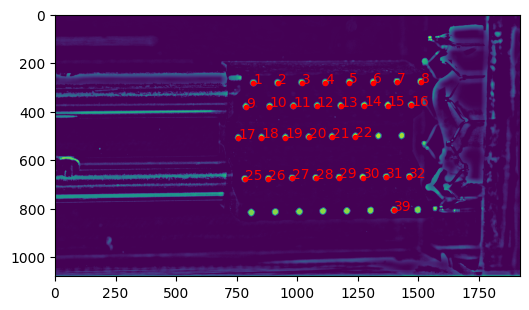

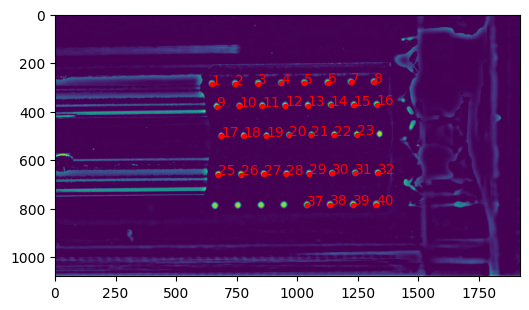

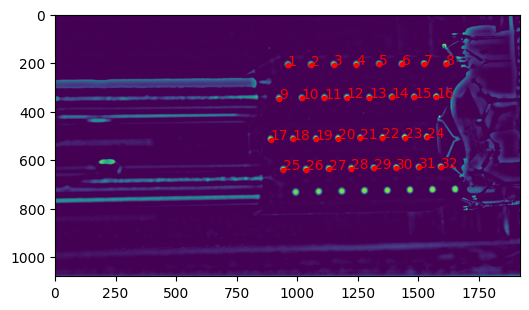

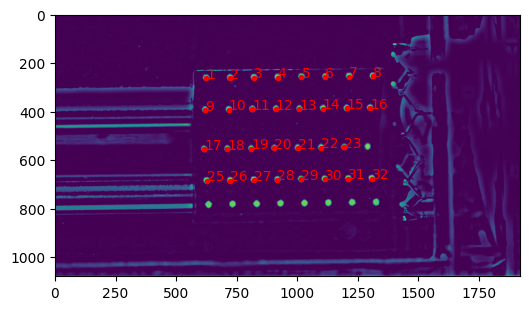

In [35]:
# sortgrid
"""
Uses sortgrid function of liboptv to match between the
calibration points in the fixp target file and the targets
detected in the images
"""
sorted_targs = []
for i_cam in range(n_cams):
    fig, ax = plt.subplots(figsize=(6,6))

    targs = match_detection_to_ref(
        cals[i_cam],
        cal_points["pos"],
        detections[i_cam],
        cpar,
    )
    x, y, pnr = [], [], []
    for t in targs:
        if t.pnr() != -999:
            pnr.append(cal_points["id"][t.pnr()])
            x.append(t.pos()[0])
            y.append(t.pos()[1])

    ax.imshow(high_passed[i_cam])
    ax.scatter(x,y,marker='.', color='r')
    for xx,yy,ss in zip(x,y,pnr):
        ax.text(xx,yy,ss,color='r')
    # ax.text(x,y,pnr)
    
    sorted_targs.append(targs)

In [58]:
# full calibration

"""
fine tuning of ORI and ADDPAR

"""
scale = 5000

op = par.OrientParams()
op.read()

# recognized names for the flags:
names = [
    "cc",
    "xh",
    "yh",
    "k1",
    "k2",
    "k3",
    "p1",
    "p2",
    "scale",
    "shear",
]
op_names = [
    op.cc,
    op.xh,
    op.yh,
    op.k1,
    op.k2,
    op.k3,
    op.p1,
    op.p2,
    op.scale,
    op.shear,
]

flags = []
for name, op_name in zip(names, op_names):
    if op_name == 1:
        flags.append(name)

print(flags)

['cc']


In [72]:
sum_residuals = []
for num_iterations in range(10):
    # for num_iterations in range(1000):
    for i_cam in range(n_cams):  # iterate over all cameras

        targs = sorted_targs[i_cam]

        # print('Before fine tuning')
        # print(cals[i_cam].get_pos())
        # print(cals[i_cam].get_angles())

        pos = cals[i_cam].get_pos()
        ang = cals[i_cam].get_angles()

        residuals, targ_ix, err_est = full_calibration(
            cals[i_cam],
            cal_points["pos"],
            targs,
            cpar,
            flags,
        )

        sum_residuals.append(np.sum(residuals))

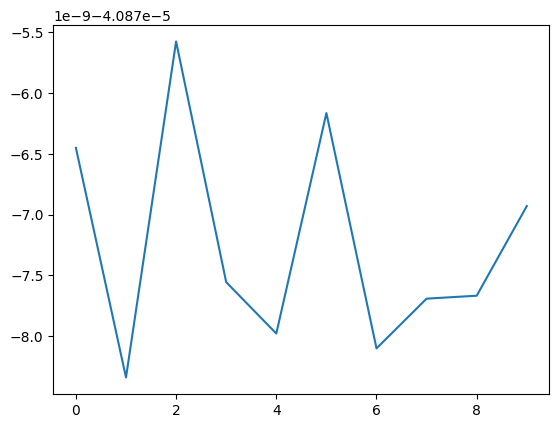

In [73]:
plt.figure()
plt.plot(sum_residuals[::4])

In [ ]:
# # save the results
# _write_ori(i_cam, addpar_flag=True)

# # Plot the output
# # reset_plots()

# x, y = [], []
# for r, t in zip(residuals, targ_ix):
#     if t != -999:
#         pos = targs[t].pos()
#         x.append(pos[0])
#         y.append(pos[1])

# camera[i_cam]._plot.overlays.clear()
# drawcross("orient_x",
#                "orient_y",
#                x,
#                y,
#                "orange",
#                5,
#                i_cam=i_cam)

# # camera[i]._plot_data.set_data(
# #     'imagedata', ori_img[i].astype(np.float))
# # camera[i]._img_plot = camera[
# #     i]._plot.img_plot('imagedata', colormap=gray)[0]
# camera[i_cam].drawquiver(
#     x,
#     y,
#     x + scale * residuals[:len(x), 0],
#     y + scale * residuals[:len(x), 1],
#     "red",
# )
# # camera[i]._plot.index_mapper.range.set_bounds(0, h_pixel)
# # camera[i]._plot.value_mapper.range.set_bounds(0, v_pixel)

# status_text = "Orientation finished."

In [133]:
# from pbi 
def fitness(solution, calib_targs, calib_detect, cpar):
    """
    Checks the fitness of an evolutionary solution of calibration values to 
    target points. Fitness is the sum of squares of the distance from each 
    guessed point to the closest neighbor.
    
    Arguments:
    solution - array, concatenated: position of intersection with Z=0 plane; 3 
        angles of exterior calibration; primary point (xh,yh,cc); 3 radial
        distortion parameters; 2 decentering parameters.
    calib_targs - a (p,3) array of p known points on the calibration target.
    calib_detect - a (d,2) array of d detected points in the calibration 
        target.
    cpar - a ControlParams object with image data.
    """
    # Breakdown of of agregate solution vector:
    inters = np.zeros(3)
    inters[:2] = solution[:2]
    R = solution[2]
    angs = solution[3:6]
    prim_point = solution[6:9]
    rad_dist = solution[9:12]
    decent = solution[12:14]
    
    # Compare known points' projections to detections:
    cal = gen_calib(inters, R, angs, glass_vec, prim_point, rad_dist,
                    decent)
    known_proj = image_coordinates(calib_targs, cal,
                                    cpar.get_multimedia_params())
    known_2d = convert_arr_metric_to_pixel(known_proj, cpar)
    dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                            axis=2).min(axis=0)

    return np.sum(dists**2)

In [134]:
def full_calibration(
                    cal: Calibration,
                    calib_detect: np.ndarray,
                    calib_targs: np.ndarray,
                    cpar: ControlParams,
                    flags,
                )-> Calibration:
    """ New full calibration using scipy minimize

    Returns:
        _type_: _description_
    """
    
    # define partial function to keep the arguments
    solution = parse_calib(cal)
    res = minimize(fitness, 
                            solution,
                            args = (
                                calib_targs, 
                                calib_detect, 
                                cpar)
    )
    
    res_cal = gen_calib(res)

    # res is the cal object that minimizes the fitness
    err_est = fitness(res_cal, calib_targs, calib_detect, cpar)
    

    return res_cal, err_est

In [135]:
def get_pos(inters, R, angs):
    # Transpose of http://planning.cs.uiuc.edu/node102.html
    # Also consider the angles are reversed when moving from camera frame to
    # global frame.
    s = np.sin(angs)
    c = np.cos(angs)
    pos = inters + R*np.r_[ s[1], -c[1]*s[0], c[1]*c[0] ]
    return pos

In [136]:
def get_polar_rep(pos, angs):
    """
    Returns the point of intersection with zero Z plane, and distance from it.
    """
    s = np.sin(angs)
    c = np.cos(angs)
    zdir = -np.r_[ s[1], -c[1]*s[0], c[1]*c[0] ]
    
    c = -pos[2]/zdir[2]
    inters = pos + c*zdir
    R = np.linalg.norm(inters - pos)
    
    return inters[:2], R

In [137]:
def gen_calib(inters, R, angs, glass_vec, prim_point, radial_dist, decent):
    pos = get_pos(inters, R, angs)
    return Calibration(pos, angs, prim_point, radial_dist, decent, 
        np.r_[1, 0], glass_vec)

In [138]:
    
def parse_calib(
    cal: Calibration
    )-> np.ndarray:
    """parse calibration to solution

    Args:
        cal (Calibration): _description_

    Returns:
        np.ndarray: solution array
    """
    
    # Inverse it: 
    
    # Breakdown of of agregate solution vector:
    # inters = np.zeros(3)
    # inters[:2] = solution[:2]
    # R = solution[2]
    # angs = solution[3:6]
    # prim_point = solution[6:9]
    # rad_dist = solution[9:12]
    # decent = solution[12:14]
    
    inters = cal.get_pos() # including R
    angs = cal.get_angles()
    primary_point = cal.get_primary_point()
    rad_dist = cal.get_radial_distortion()
    decent = cal.get_decentering()
    
    return np.r_[inters, angs, primary_point, rad_dist, decent]

In [159]:
def copy_calibration(cal):
    return Calibration(cal.get_pos(), 
                      cal.get_angles(), 
                      cal.get_primary_point(), 
                      cal.get_radial_distortion(), 
                      cal.get_decentering(), 
                      cal.get_affine(), 
                      cal.get_glass_vec())
    

In [161]:
def project_cal_points(cal_points, calibration, cpar):
    x, y = [], []
    for row in cal_points:
        projected = image_coordinates(
            np.atleast_2d(row["pos"]),
            calibration,
            cpar.get_multimedia_params(),
        )
        pos = convert_arr_metric_to_pixel(projected, cpar)

        x.append(pos[0][0])
        y.append(pos[0][1])
        
    return x,y

In [182]:
def get_targs(calibration, cal_points, detections, cpar):
    """gets matching targets in x,y """
    targs = match_detection_to_ref(
        calibration,
        cal_points["pos"],
        detections,
        cpar,
    )
    x, y, pnr = [], [], []
    for t in targs:
        if t.pnr() != -999:
            pnr.append(cal_points["id"][t.pnr()])
            x.append(t.pos()[0])
            y.append(t.pos()[1])
    return x,y


solution is [-5.53583407e+01  6.94270475e+01  2.87072146e+02 -2.68030643e-01
 -2.01922695e-01 -1.87880954e-02  0.00000000e+00  3.00000000e-04
  1.00474479e+02  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
error is 270221.7789894774


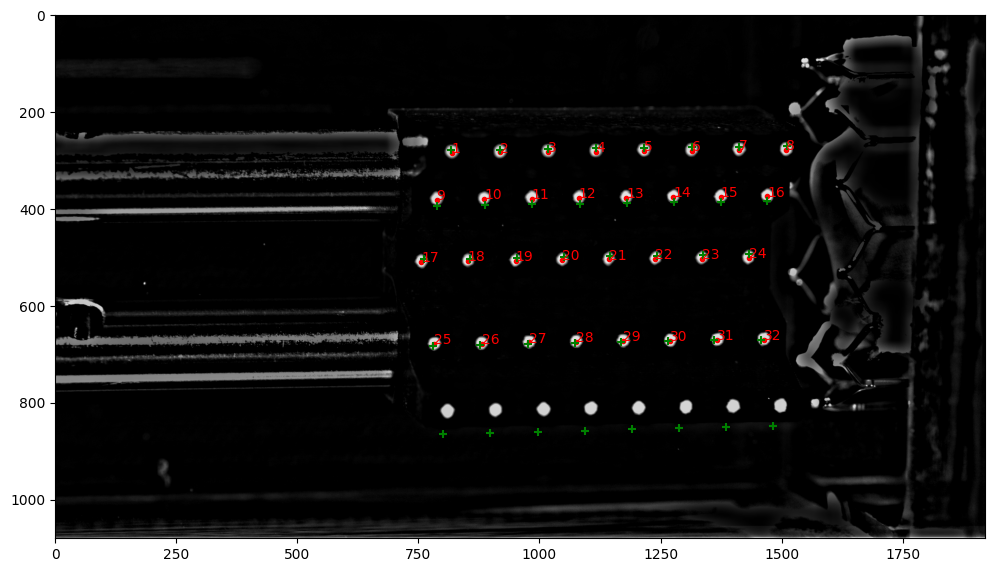

In [186]:
# for i_cam in range(1):
i_cam = 0
fig, ax = plt.subplots(figsize=(12,12))


tmp = copy_calibration(cals[i_cam])
solution = parse_calib(tmp)
print(f'solution is {solution}')

x,y = get_targs(tmp, cal_points, detections[i_cam], cpar)


ax.imshow(high_passed[i_cam],cmap='gray')
ax.scatter(x,y,marker='.', color='r')
for xx,yy,ss in zip(x,y,pnr):
    ax.text(xx,yy,ss,color='r')

xc,yc = project_cal_points(cal_points, tmp, cpar)
ax.scatter(xc, yc, 30, marker='+',color='g')
known_2d = np.c_[xc,yc]
calib_detect = np.c_[x,y]

dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                        axis=2).min(axis=0)


print(f'error is {np.sum(dists**2)}')
    
    # return np.sum(dists**2)
    

solution is [-5.53583407e+01  6.94270475e+01  2.87072146e+02 -2.68030643e-01
 -2.01922695e-01 -1.87880954e-02  0.00000000e+00  3.00000000e-04
  1.00474479e+02  1.00000000e-02  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
error is 1286394.7287837055


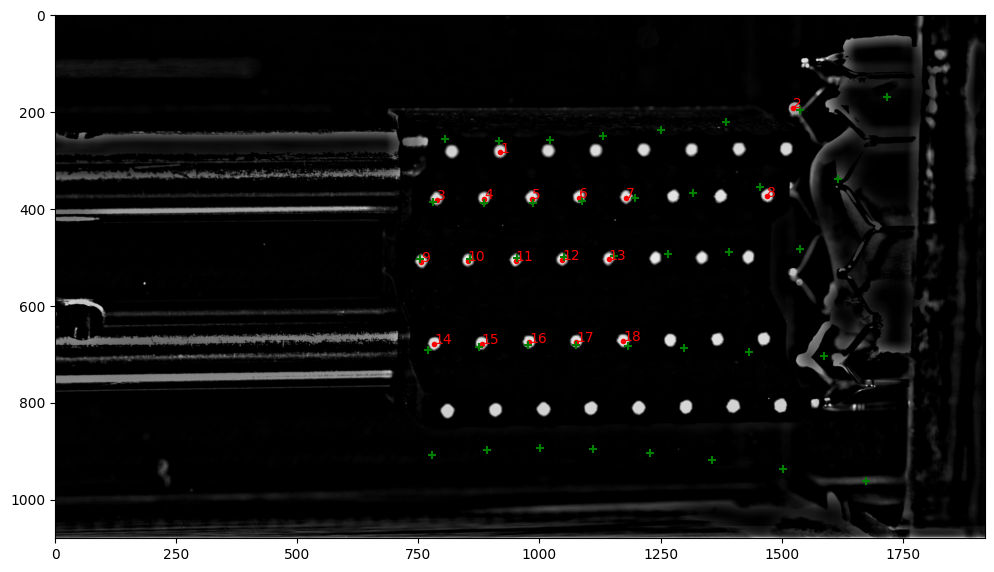

In [194]:
# for i_cam in range(1):
i_cam = 0
fig, ax = plt.subplots(figsize=(12,12))


tmp = copy_calibration(cals[i_cam])

# change one parameter at a time

eps = 0.01
# print(tmp.get_radial_distortion())


tmp.set_radial_distortion(tmp.get_radial_distortion() + np.array([eps, 0, 0]))
# print(tmp.get_radial_distortion())
# solution = parse_calib(tmp)
print(f'solution is {parse_calib(tmp)}')


x,y = get_targs(tmp, cal_points, detections[i_cam], cpar)


ax.imshow(high_passed[i_cam],cmap='gray')
ax.scatter(x,y,marker='.', color='r')
for xx,yy,ss in zip(x,y,pnr):
    ax.text(xx,yy,ss,color='r')

xc,yc = project_cal_points(cal_points, tmp, cpar)
ax.scatter(xc, yc, 30, marker='+',color='g')
known_2d = np.c_[xc,yc]
calib_detect = np.c_[x,y]

dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                        axis=2).min(axis=0)


print(f'error is {np.sum(dists**2)}')

In [223]:
i_cam = 0
# , ax = plt.subplots(figsize=(12,12))
tmp = copy_calibration(cals[i_cam])

def fitness(eps):
    # for i_cam in range(1):
    
    rd = tmp.get_radial_distortion()
    rd[0] = eps
    tmp.set_radial_distortion(rd)
    # tmp.set_radial_distortion(tmp.get_radial_distortion() + np.array([eps, 0, 0]))
    # print(tmp.get_radial_distortion())

    # print(f'solution is {parse_calib(tmp)}')


    x,y = get_targs(tmp, cal_points, detections[i_cam], cpar)


    # ax.imshow(high_passed[i_cam],cmap='gray')
    # ax.scatter(x,y,marker='.', color='r')
#     for xx,yy,ss in zip(x,y,pnr):
#         ax.text(xx,yy,ss,color='r')

    xc,yc = project_cal_points(cal_points, tmp, cpar)
    # ax.scatter(xc, yc, 30, marker='+',color='g')
    known_2d = np.c_[xc,yc]
    calib_detect = np.c_[x,y]

    dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                            axis=2).min(axis=0)


    # print(f'error is {np.sum(dists**2)}')
    
    return np.sum(dists**2)

In [224]:
from scipy.optimize import minimize
sol = minimize(fitness, 0.0, method='Nelder-Mead',options ={'disp':True})

Optimization terminated successfully.
         Current function value: 251444.231097
         Iterations: 44
         Function evaluations: 88


In [225]:
sol.x

array([-0.00123989])

solution is [-5.53583407e+01  6.94270475e+01  2.87072146e+02 -2.68030643e-01
 -2.01922695e-01 -1.87880954e-02  0.00000000e+00  3.00000000e-04
  1.00474479e+02 -1.23988889e-03  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
error is 251444.23109700647


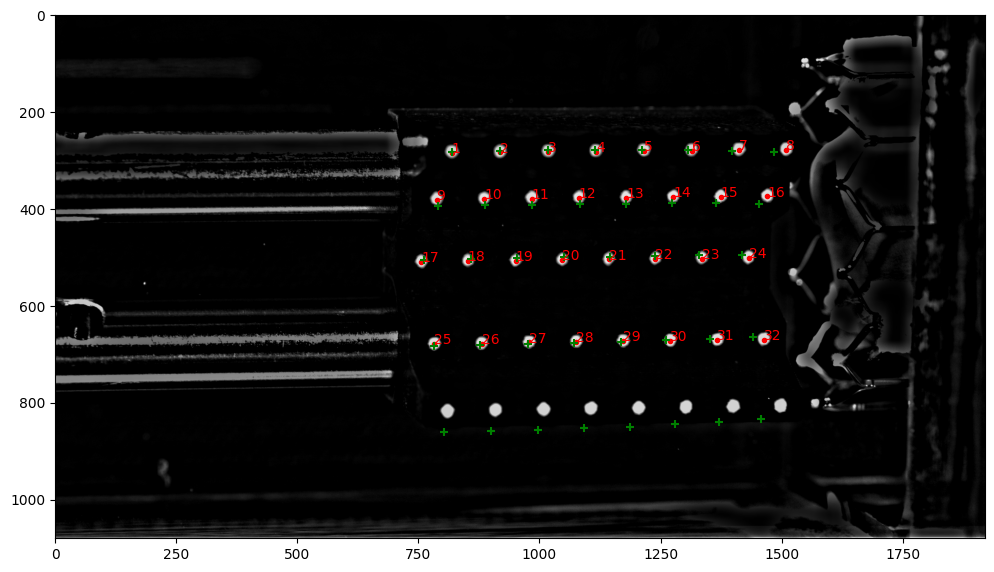

In [227]:
# for i_cam in range(1):
i_cam = 0
fig, ax = plt.subplots(figsize=(12,12))


tmp = copy_calibration(cals[i_cam])

rd = tmp.get_radial_distortion()
rd[0] = sol.x
tmp.set_radial_distortion(rd)

solution = parse_calib(tmp)
print(f'solution is {solution}')

x,y = get_targs(tmp, cal_points, detections[i_cam], cpar)


ax.imshow(high_passed[i_cam],cmap='gray')
ax.scatter(x,y,marker='.', color='r')
for xx,yy,ss in zip(x,y,pnr):
    ax.text(xx,yy,ss,color='r')

xc,yc = project_cal_points(cal_points, tmp, cpar)
ax.scatter(xc, yc, 30, marker='+',color='g')
known_2d = np.c_[xc,yc]
calib_detect = np.c_[x,y]

dists = np.linalg.norm(known_2d[None, :, :] - calib_detect[:, None, :],
                        axis=2).min(axis=0)


print(f'error is {np.sum(dists**2)}')